# 01 — LFP 域内训练（源域模型）

**目标**：用已提取好的 LFP 50 维特征，训练 SOHNet，产出三件"迁移行李"：
1. `sohnet_lfp.pt` — 预训练权重
2. `norm_lfp.npz` — 训练集上拟合的逐特征 min-max（**只在 LFP 域内使用**；NCA 域将拟合自己的，见 notebook 03）
3. `colmap.json` — 列名约定，保证 NCA 侧特征表能对上同一输入顺序

**数据划分原则**：按**电池 ID** 切分（blind test），不是按行随机切——同一颗电池的相邻循环高度相似，按行切会把"同一颗电池的信息"泄漏进测试集，R² 会虚高。

In [1]:
# ---- Cell 1: 配置区 ----
import glob, re, json, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

TRAIN_DIR   = "X_train"
TEST_DIR    = "X_test_noleak"
TEST_Y_DIR  = "y_test_secret"

SEQ_COLS  = ([f"Q_{i}"  for i in range(16)] +
             [f"dQ_{i}" for i in range(16)] +
             [f"IC_{i}" for i in range(16)])
SCAL_COLS = ["h_peak", "dVpeak"]
FEAT_COLS = SEQ_COLS + SCAL_COLS

SEED = 42
VAL_FRAC = 0.12
Y_LO, Y_HI = 50.0, 105.0
BATCH, EPOCHS, PATIENCE = 256, 300, 25
LR, WEIGHT_DECAY, DROPOUT = 1e-3, 1e-4, 0.15
DEV = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("device:", DEV)

device: cpu


In [2]:
# ---- Cell 2: 读数据 + 切验证集 ----
def read_train():
    Xs, ys, bids = [], [], []
    for f in sorted(glob.glob(f"{TRAIN_DIR}/X_*.csv")):
        d = pd.read_csv(f)
        Xs.append(d[FEAT_COLS].to_numpy(np.float32))
        ys.append(d["SOH"].to_numpy(np.float32))
        bids.append(np.full(len(d), re.search(r"X_(\d+)", f).group(1)))
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(bids)

def read_test():
    Xs, ys, bids = [], [], []
    for f in sorted(glob.glob(f"{TEST_DIR}/X_*.csv")):
        bid = re.search(r"X_(\d+)", f).group(1)
        x = pd.read_csv(f)
        y = pd.read_csv(f"{TEST_Y_DIR}/y_{bid}.csv")
        Xs.append(x[FEAT_COLS].to_numpy(np.float32))
        ys.append(y["SOH"].to_numpy(np.float32))
        bids.append(np.full(len(x), bid))
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(bids)

X_all, y_all, bid_all = read_train()
Xte, yte, bid_te = read_test()

cells = np.unique(bid_all)
rng = np.random.default_rng(SEED); rng.shuffle(cells)
m_va = np.isin(bid_all, cells[:max(1, int(len(cells)*VAL_FRAC))])
Xtr, ytr = X_all[~m_va], y_all[~m_va]
Xva, yva = X_all[m_va],  y_all[m_va]

print(f"train {len(np.unique(bid_all[~m_va]))} cells / val {len(np.unique(bid_all[m_va]))} cells "
      f"/ test {len(np.unique(bid_te))} cells")
print("rows:", Xtr.shape, Xva.shape, Xte.shape)

train 215 cells / val 29 cells / test 28 cells
rows: (1761189, 50) (228242, 50) (209920, 50)


## 归一化：为什么只在训练集上拟合

min-max 的 `min/max` 是模型的一部分。如果用全体数据（含测试集）算，就把测试集的分布信息喂给了模型——这叫**数据泄漏**，会让盲测数字不可信。所以：`x_min/x_max` 只从 TRAIN 行统计，val/test 用同一组参数变换。

标签 y 不做数据驱动归一化，而是映射到**固定区间** [50, 105]→[0,1]。固定区间的意义在于：LFP 和 NCA 未来共享同一个输出坐标系——SOH 90% 在两个域里都是同一个数，网络输出层不需要为换域而重学刻度。

In [3]:
# ---- Cell 3: 拟合归一化(仅TRAIN) + 打包DataLoader ----
x_min = Xtr.min(axis=0); x_max = Xtr.max(axis=0)
span = np.where(x_max - x_min < 1e-12, 1.0, x_max - x_min)   # 防零除

def norm_x(X): return ((X - x_min) / span).astype(np.float32)
def norm_y(y): return ((y - Y_LO) / (Y_HI - Y_LO)).astype(np.float32)
def denorm_y(yn): return yn * (Y_HI - Y_LO) + Y_LO

def make_loader(X, y, shuffle):
    ds = TensorDataset(torch.from_numpy(norm_x(X)), torch.from_numpy(norm_y(y)))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

tr_loader = make_loader(Xtr, ytr, True)
va_loader = make_loader(Xva, yva, False)
te_loader = make_loader(Xte, yte, False) if yte is not None else None

np.savez("norm_lfp.npz", x_min=x_min, x_max=x_max, y_lo=Y_LO, y_hi=Y_HI)
json.dump({"SEQ_COLS": SEQ_COLS, "SCAL_COLS": SCAL_COLS},
          open("colmap.json","w"), ensure_ascii=False, indent=1)
print("saved norm_lfp.npz, colmap.json")

saved norm_lfp.npz, colmap.json


## SOHNet 结构：谁看什么

输入 50 维拆两路——**序列路**（48 维 reshape 成 3 通道 × 16 点，进卷积）和**标量路**（h_peak、ΔVpeak，2 维，跳过卷积直通全连接）。标量没有"局部形状"可提取，让它过卷积毫无意义，所以走旁路。

卷积骨干是两个 block（笔画→部件）：
- Conv1d(3→32, k=3)：每个滤波器只看相邻 3 个点，学的是**最局部的形状元件**——上升沿、下降沿、小凸起（"笔画"）。
- Conv1d(32→64, k=3)：输入已是上一层的输出，它把笔画拼成**部件**——峰的侧翼、拐点组合。
- AdaptiveAvgPool1d(4)：把任意长度压成 4 个"区段平均"，既降维又给一点平移容忍。

回归头三层全连接把 `64×4 + 2 = 258` 维压到 1 个 SOH。注意参数量分布：骨干约 6.7k，头约 37k——**头占全网 ~85%**。这个事实在迁移阶段很重要（见 notebook 03 的讨论）。

In [4]:
# ---- Cell 4: SOHNet ----
class SOHNet(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()
        self.conv = nn.Sequential(
            # 通道翻倍：3->64->128
            nn.Conv1d(3, 64, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(4),   # 输出 128*4 = 512 维
        )
        self.head = nn.Sequential(
            # 输入 512(特征) + 2(标量) = 514
            nn.Linear(514, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
    def forward(self, x):                 # x: (B,50) 已归一化
        seq  = x[:, :48].reshape(-1, 3, 16)   # 3通道×16点
        scal = x[:, 48:]                      # 2标量旁路
        f = self.conv(seq).flatten(1)         # (B,256)
        return self.head(torch.cat([f, scal], dim=1)).squeeze(-1)

model = SOHNet().to(DEV)
n_conv = sum(p.numel() for p in model.conv.parameters())
n_head = sum(p.numel() for p in model.head.parameters())
print(f"params: conv {n_conv}, head {n_head}, head占比 {n_head/(n_conv+n_head):.0%}")

params: conv 25728, head 148353, head占比 85%


In [7]:
# ---- Cell 5: 训练(早停) ----
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
lossf = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.5, patience=8, min_lr=1e-6  # <--- 删掉了 verbose=True
)

def eval_rmse(loader):
    model.eval(); errs = []
    with torch.no_grad():
        for xb, yb in loader:
            p = model(xb.to(DEV)).cpu().numpy()
            errs.append((denorm_y(p) - denorm_y(yb.numpy()))**2)
    return float(np.sqrt(np.concatenate(errs).mean()))

best, bad = 1e9, 0
for ep in range(1, EPOCHS+1):
    model.train()
    tr_loss_sum = 0.0                              # <--- 新增：每轮开始前重置累计损失
    
    for xb, yb in tr_loader:
        opt.zero_grad()
        loss = lossf(model(xb.to(DEV)), yb.to(DEV))
        loss.backward()
        opt.step()
        tr_loss_sum += loss.item()                 # <--- 新增：累加当前batch的损失值
    
    # 计算当前epoch的平均训练损失
    tr_loss_avg = tr_loss_sum / len(tr_loader)     # <--- 新增
    
    v = eval_rmse(va_loader)
    scheduler.step(v)
    
    if v < best - 1e-3:
        best, bad = v, 0
        torch.save(model.state_dict(), "sohnet_lfp.pt")
    else:
        bad += 1
    
    # 修改了打印行，加上了训练损失和学习率
    if ep % 10 == 0 or bad == 0:
        current_lr = opt.param_groups[0]['lr']      # <--- 新增：获取当前学习率
        print(f"ep{ep:3d}  tr_loss={tr_loss_avg:.4f}  val RMSE {v:.3f}%  (best {best:.3f}%)  LR={current_lr:.2e}")
    
    if bad >= PATIENCE:
        print(f"early stop @ ep{ep}")
        break

ep  1  tr_loss=0.0011  val RMSE 2.361%  (best 2.361%)  LR=1.00e-03
ep  2  tr_loss=0.0010  val RMSE 1.773%  (best 1.773%)  LR=1.00e-03
ep  3  tr_loss=0.0009  val RMSE 1.648%  (best 1.648%)  LR=1.00e-03
ep 10  tr_loss=0.0009  val RMSE 1.983%  (best 1.648%)  LR=1.00e-03
ep 13  tr_loss=0.0007  val RMSE 1.630%  (best 1.630%)  LR=5.00e-04
ep 17  tr_loss=0.0007  val RMSE 1.599%  (best 1.599%)  LR=5.00e-04
ep 18  tr_loss=0.0007  val RMSE 1.559%  (best 1.559%)  LR=5.00e-04
ep 20  tr_loss=0.0007  val RMSE 1.825%  (best 1.559%)  LR=5.00e-04
ep 29  tr_loss=0.0006  val RMSE 1.520%  (best 1.520%)  LR=2.50e-04
ep 30  tr_loss=0.0006  val RMSE 1.503%  (best 1.503%)  LR=2.50e-04
ep 40  tr_loss=0.0005  val RMSE 1.515%  (best 1.503%)  LR=1.25e-04
ep 42  tr_loss=0.0005  val RMSE 1.465%  (best 1.465%)  LR=1.25e-04
ep 45  tr_loss=0.0005  val RMSE 1.456%  (best 1.456%)  LR=1.25e-04
ep 50  tr_loss=0.0005  val RMSE 1.623%  (best 1.456%)  LR=1.25e-04
ep 58  tr_loss=0.0005  val RMSE 1.433%  (best 1.433%)  LR=6.25

BLIND TEST  RMSE=1.605%   R2=0.9337   (cells: ['021', '025', '050', '061', '086', '099', '107', '123', '155', '163', '164', '176', '178', '183', '206', '237', '247', '257', '258', '405', '414', '416', '421', '450', '455', '475', '490', '594'])


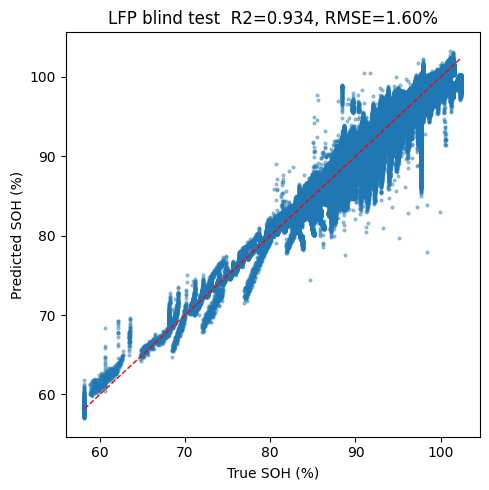

In [8]:
# ---- Cell 6: 盲测 ----
import matplotlib.pyplot as plt
model.load_state_dict(torch.load("sohnet_lfp.pt"))
model.eval()

# 定义测试集电池编号（因为 bid_te 在 Cell 2 中已经定义）
TEST_CELLS = np.unique(bid_te).tolist()   # <--- 新增

preds, trues = [], []
with torch.no_grad():
    for xb, yb in te_loader:
        preds.append(denorm_y(model(xb.to(DEV)).cpu().numpy()))
        trues.append(denorm_y(yb.numpy()))
preds, trues = np.concatenate(preds), np.concatenate(trues)
rmse = float(np.sqrt(((preds-trues)**2).mean()))
r2 = 1 - ((preds-trues)**2).sum()/((trues-trues.mean())**2).sum()
print(f"BLIND TEST  RMSE={rmse:.3f}%   R2={r2:.4f}   (cells: {TEST_CELLS})")

plt.figure(figsize=(5,5))
plt.scatter(trues, preds, s=4, alpha=0.4)
lo, hi = trues.min(), trues.max()
plt.plot([lo,hi],[lo,hi],'r--',lw=1)
plt.xlabel('True SOH (%)')
plt.ylabel('Predicted SOH (%)')
plt.title(f'LFP blind test  R2={r2:.3f}, RMSE={rmse:.2f}%')
plt.tight_layout()
plt.savefig('lfp_parity.png', dpi=150)
plt.show()

In [9]:
# 1 nca全生命周期波形提取
# 2 选择老化信息最强的峰 确定电压窗口
# 3 在多个nca电池上尝试提取峰附近信息